# Material ID : mp-961673

In [2]:
import json

# An optional utility to display a progress bar
# for long-running loops. `pip install tqdm`.
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from mp_api.client import MPRester

from jupyter_jsmol import JsmolView
from ipywidgets import Layout, widgets, interact
from IPython.display import display, Image
import os
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from jupyter_jsmol.pymatgen import quick_view
#from pymatgen.electronic_structure import plotter
#from pymatgen.electronic_structure import bandstructure as bs

import matplotlib.pyplot as plt
import numpy as np
from pymatgen.phonon import plotter
from pymatgen.phonon import bandstructure
from math import pi, fabs

api_key = "IDG8oerg7OP5AeRfbNjUZBb1Ad4Qke2l"
material_id = "mp-961673"

mpr = MPRester(api_key)

structure = mpr.get_structure_by_material_id(material_id)
phonons   = mpr.get_phonon_bandstructure_by_material_id(material_id) 

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving PhononBSDOSDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

# Télécharger la structure de bande de phonons

<Axes: xlabel='$\\mathrm{Wave\\ Vector}$', ylabel='$\\mathrm{Frequencies\\ (THz)}$'>

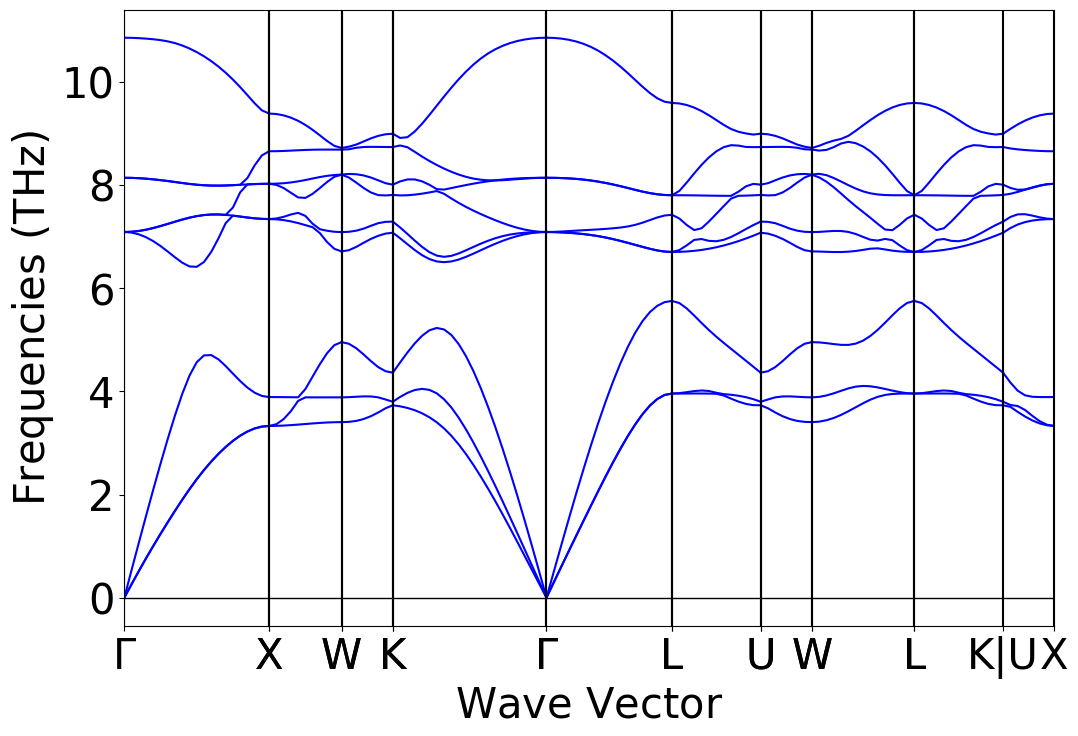

In [3]:
ph_plot = plotter.PhononBSPlotter(phonons)
ph_plot.get_plot()

# Identifier la zone de Brillouin

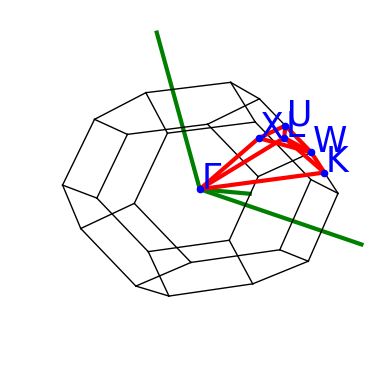

In [4]:
ph_plot.plot_brillouin() 

# Calculer la vitesse du son pour trois branches acoustiques différentes dans trois directions différentes de la zone de Brillouin

In [5]:
data = ph_plot.bs_plot_data()
distances   = data.get("distances")
frequencies = data.get("frequency")
directions  = data.get('ticks').get('label')

zone    = []
branch  = []
freq    = []

for i in range(len(frequencies)):
    for j in range(len(frequencies[i])):
        if i not in zone and j not in branch and frequencies[i][j][0] == 0 :
            zone.append(i)
            branch.append(j)
            freq.append(frequencies[i][j])
        elif i not in zone and j not in branch and frequencies[i][j][-1] == 0 :
            zone.append(i)
            branch.append(j)
            freq.append(frequencies[i][j])
            
print("Branches :", branch)
print("Zones : ", zone)
print("Frequences : ", freq)

Branches : [0, 1, 2]
Zones :  [0, 3, 4]
Frequences :  [[0.0, 0.2594214632091062, 0.5147861965722326, 0.7631554571126292, 1.003470463605915, 1.23645184142343, 1.463426566492444, 1.684758233900819, 1.899072957075097, 2.1037882724188384, 2.2963193681109413, 2.474990039046014, 2.639148535950505, 2.7886157882695177, 2.9229703950753922, 3.0411553308992247, 3.1415435192979335, 3.2222573491195297, 3.2814851113352215, 3.31771099601345, 3.3299085385597764], [3.7995197459954313, 3.8926263679716286, 3.9715046490453103, 4.026834586153665, 4.048966566419285, 4.029342075809107, 3.9624939288811922, 3.847563012933991, 3.688189668949188, 3.490897040110236, 3.2631517786777455, 3.0119830507103678, 2.7432699959132454, 2.4615018509152558, 2.1698671285645252, 1.8705881610546966, 1.5653720326095533, 1.2557760037196597, 0.9433169857682895, 0.629326456967422, 0.31473483329466256, 0.0], [0.0, 0.508955300972788, 1.0152971816844227, 1.515821167598328, 2.006687937027476, 2.483836240267895, 2.943399403106436, 3.3818

In [6]:
# 3 distances
d1 = distances[zone[0]]
d2 = distances[zone[1]]
d3 = distances[zone[2]]

# Frequencies for those distances
freq1 = freq[0]
freq2 = freq[1]
freq3 = freq[2]
    
# Slope for first branch
x1 = np.array([d1[0],d1[1]])
y1 = np.array([freq1[0],freq1[1]])
coef1 = np.polyfit(x1,y1,1)

# Slope for second branch
x2 = np.array([d2[-1],d2[-2]])
y2 = np.array([freq2[-1],freq2[-2]])
coef2 = np.polyfit(x2,y2,1)

# Slope for thrid branch
x3 = np.array([d3[0],d3[1]])
y3 = np.array([freq3[0],freq3[1]])
coef3 = np.polyfit(x3,y3,1)

# Corrective Factor
# 1 Angstrom = 10^{-10} m
# 1 THz = 10^{12} Hz
fact = 10**(-10) * 10**(12)

print("La vitesse du son de la branche acoustique", branch[0]+1, "selon la direction \u0393 - X est de ", 2*pi*fabs(coef1[0])*fact, "[m/s].")
print("La vitesse du son de la branche acoustique", branch[1]+1, "selon la direction K - \u0393 est de ", 2*pi*fabs(coef2[0])*fact, "[m/s].")
print("La vitesse du son de la branche acoustique", branch[2]+1, "selon la direction \u0393 - L est de ", 2*pi*fabs(coef3[0])*fact, "[m/s].")

La vitesse du son de la branche acoustique 1 selon la direction Γ - X est de  3016.101679218454 [m/s].
La vitesse du son de la branche acoustique 2 selon la direction K - Γ est de  3622.4126590488445 [m/s].
La vitesse du son de la branche acoustique 3 selon la direction Γ - L est de  5807.751290466143 [m/s].
